# 02 — Approche semi-supervisée et comparaison avec une baseline supervisée

**Mission BrainScanAI — *CurelyticsIA*** &nbsp;·&nbsp; *Option B*

Ce second notebook met en œuvre l'**étape 4** de la mission :

1. Charger les pseudo-labels faibles (issus du clustering du notebook 01) et
   les 100 labels forts (sans jamais mélanger les deux jeux).
2. Réaliser un split *train / test* stratifié sur les labels forts (le test set
   restera **strictement inconnu** des deux modèles).
3. Entraîner :
   - une **baseline supervisée pure** (ResNet18 + tête 2 classes, fine-tuné
     uniquement sur les 80 images fortement labellisées du train) ;
   - une **approche semi-supervisée** (même architecture, pré-entraînée sur les
     ~1 400 pseudo-labels faibles, puis fine-tunée sur les mêmes 80 images).
4. Comparer les performances : accuracy, macro-F1, **recall de la classe
   *cancer*** (priorité métier), précision, ROC AUC, matrice de confusion.
5. Conclusion / *Definition of Done*.

## 0. Imports & configuration

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from curelyticsia.config import (
    CLASS_TO_INDEX,
    CLASSES,
    FIGURES_DIR,
    PROCESSED_DIR,
    SEED,
    ClusteringConfig,
    FeatureConfig,
    TrainingConfig,
    ensure_dirs,
    set_global_seeds,
)
from curelyticsia.features.extractor import load_cached_features
from curelyticsia.viz.plots import (
    plot_confusion_matrix,
    plot_history,
    plot_metrics_bar,
)

ensure_dirs()
set_global_seeds(SEED)
print("Classes :", CLASSES, "→", CLASS_TO_INDEX)

Classes : ('normal', 'cancer') → {'normal': 0, 'cancer': 1}


## 1. Chargement des features et des labels

In [2]:
features, index_df = load_cached_features(FeatureConfig().cache_path)
weak = pd.read_csv(ClusteringConfig().weak_labels_path)
print(f"features            : {features.shape}")
print(f"index_df            : {index_df.shape}")
print(f"pseudo-labels faibles : {len(weak)}")

labeled_df = index_df[index_df["split"] == "labeled"].copy()
labeled_df["label_index"] = labeled_df["label_name"].map(CLASS_TO_INDEX).astype(int)
print("\nDistribution labels forts :")
print(labeled_df["label_name"].value_counts())

features            : (1506, 2048)
index_df            : (1506, 5)
pseudo-labels faibles : 1406

Distribution labels forts :
label_name
cancer    50
normal    50
Name: count, dtype: int64


### 1.1 Garde-fous : aucun chevauchement entre faibles et forts

In [3]:
strong_ids = set(labeled_df["image_id"])
weak_ids = set(weak["image_id"])
overlap = strong_ids & weak_ids
assert not overlap, f"Chevauchement détecté : {overlap}"
print("OK — pas de chevauchement entre labels forts et faibles")

OK — pas de chevauchement entre labels forts et faibles


## 2. Évaluation 5-fold stratifiée

Avec seulement 100 IRM fortement labellisées, un unique split train/test laisse
trop de variance d'estimation. On préfère une **5-fold stratifiée** : à chaque
fold, 50 IRM sont en train et 50 en test (jamais vues), avec ratio 1:1 cancer
/ normal préservé. Les deux stratégies (sup. pur, semi-sup.) sont évaluées sur
les **mêmes folds**, mêmes hyperparamètres, mêmes graines.

Pourquoi 50/50 plutôt que 80/20 ?

* Garder un test set substantiel (50 IRM) réduit la variance d'estimation.
* Avec 80/20, ResNet18 pré-entraîné ImageNet sature trop vite (perfect score
  sur 20 IRM) ; la comparaison perd en pouvoir discriminant.
* Le total `5 folds × 50 test = 250 prédictions` (avec *overlap*) reste
  pragmatique pour une mission exploratoire de R&D.

In [4]:
from curelyticsia.models.semi_supervised import (
    aggregate_reports,
    cross_validate,
)

cfg = TrainingConfig()
print("Hyperparamètres :", cfg)

print(f"\nStrong : {len(labeled_df)} | Weak : {len(weak)} | Folds : {cfg.cv_folds}")

Hyperparamètres : TrainingConfig(architecture='resnet18', num_classes=2, image_size=224, batch_size=16, epochs_weak=3, epochs_strong=6, learning_rate=0.0001, weight_decay=0.0001, test_size=0.5, val_size=0.0, early_stopping_patience=4, cv_folds=5)

Strong : 100 | Weak : 1406 | Folds : 5


## 3. Lancement de la cross-validation

Chaque fold lance :

1. **Stratégie A — supervisée pure** : ResNet18 pré-entraîné ImageNet,
   ré-entraîné de bout en bout sur 50 IRM fortement labellisées.
2. **Stratégie B — semi-supervisée** : même architecture, **pré-entraînée**
   sur les ~1 400 pseudo-labels faibles puis **fine-tunée** sur les mêmes 50
   IRM avec un *learning rate* divisé par deux.

Les deux stratégies sont évaluées sur les **mêmes** 50 IRM jamais vues.

In [5]:
reports = cross_validate(
    strong_paths=labeled_df["path"].tolist(),
    strong_labels=labeled_df["label_index"].tolist(),
    weak_paths=weak["path"].tolist(),
    weak_labels=weak["weak_label_index"].astype(int).tolist(),
    class_names=list(CLASSES),
    cfg=cfg,
    seed=SEED,
)

agg_sup = aggregate_reports(reports["supervised"])
agg_semi = aggregate_reports(reports["semi_supervised"])

  fold 1/5 | sup acc=0.950 f1=0.950 | semi acc=0.900 f1=0.899


  fold 2/5 | sup acc=0.950 f1=0.950 | semi acc=0.950 f1=0.950


  fold 3/5 | sup acc=0.900 f1=0.899 | semi acc=0.900 f1=0.900


  fold 4/5 | sup acc=0.950 f1=0.950 | semi acc=0.900 f1=0.899


  fold 5/5 | sup acc=0.850 f1=0.847 | semi acc=0.950 f1=0.950


## 4. Comparaison des deux stratégies

In [6]:
def to_summary(agg: dict[str, dict[str, float]]) -> dict[str, str]:
    out = {}
    for metric, vals in agg.items():
        if vals["std"] > 1e-6:
            out[metric] = f"{vals['mean']:.3f} ± {vals['std']:.3f}"
        else:
            out[metric] = f"{vals['mean']:.3f}"
    return out

comparison = pd.DataFrame({
    "Supervisé pur": to_summary(agg_sup),
    "Semi-supervisé": to_summary(agg_semi),
})
comparison

,Supervisé pur,Semi-supervisé
accuracy,0.920 ± 0.040,0.920 ± 0.024
f1_macro,0.919 ± 0.041,0.920 ± 0.025
recall_cancer,0.900 ± 0.126,0.960 ± 0.049
precision_cancer,0.945 ± 0.045,0.895 ± 0.061
f1_cancer,0.914 ± 0.051,0.924 ± 0.022
roc_auc,0.982 ± 0.018,0.958 ± 0.036


G:\Mon Drive\OC\Projet_10\CurelyticsIA\src\curelyticsia\viz\plots.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="run", y=metric_name, ax=ax, palette="muted")
G:\Mon Drive\OC\Projet_10\CurelyticsIA\src\curelyticsia\viz\plots.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="run", y=metric_name, ax=ax, palette="muted")


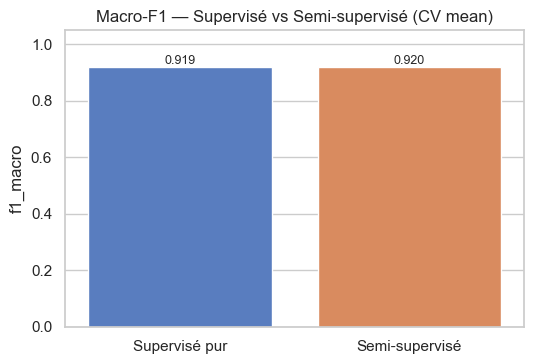

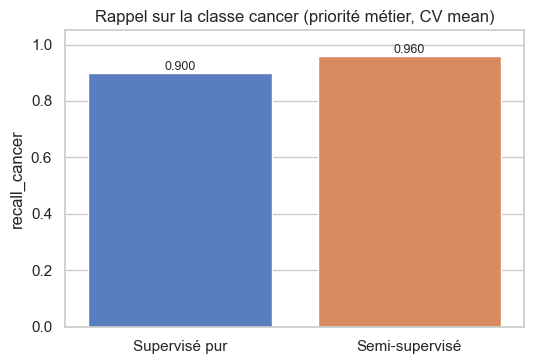

In [7]:
runs = {
    "Supervisé pur": {k: v["mean"] for k, v in agg_sup.items()},
    "Semi-supervisé": {k: v["mean"] for k, v in agg_semi.items()},
}
_ = plot_metrics_bar(
    runs,
    metric_name="f1_macro",
    title="Macro-F1 — Supervisé vs Semi-supervisé (CV mean)",
    save_path=FIGURES_DIR / "compare_f1.png",
)
_ = plot_metrics_bar(
    runs,
    metric_name="recall_cancer",
    title="Rappel sur la classe cancer (priorité métier, CV mean)",
    save_path=FIGURES_DIR / "compare_recall_cancer.png",
)

### 4.1 Matrices de confusion (somme sur les 5 folds)

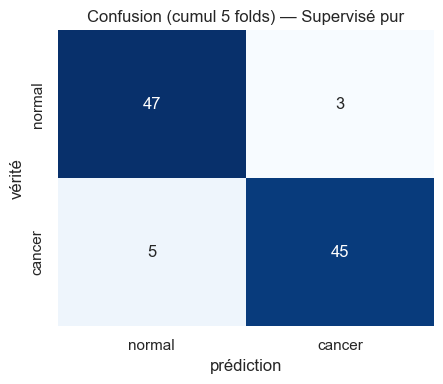

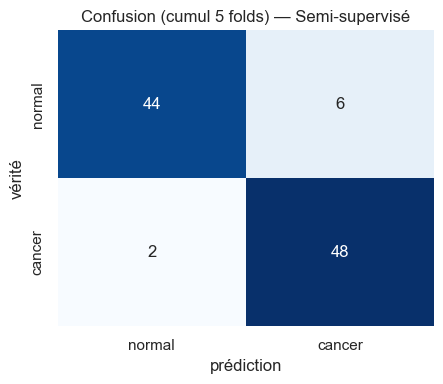

In [8]:
def stack_cm(reports_list):
    return np.sum([np.array(r.confusion_matrix) for r in reports_list], axis=0).tolist()

cm_sup = stack_cm(reports["supervised"])
cm_semi = stack_cm(reports["semi_supervised"])

_ = plot_confusion_matrix(
    cm_sup,
    class_names=list(CLASSES),
    title="Confusion (cumul 5 folds) — Supervisé pur",
    save_path=FIGURES_DIR / "cm_supervised.png",
)
_ = plot_confusion_matrix(
    cm_semi,
    class_names=list(CLASSES),
    title="Confusion (cumul 5 folds) — Semi-supervisé",
    save_path=FIGURES_DIR / "cm_semi.png",
)

### 4.2 Historique d'entraînement (un fold représentatif)

,step,phase,train_loss,train_acc
5,6,supervised/supervised,0.009302,1.000000
6,1,semi-supervised/weak,0.202926,0.923186
7,2,semi-supervised/weak,0.106880,0.960882
8,3,semi-supervised/weak,0.093145,0.964438
9,4,semi-supervised/strong,0.593420,0.875000
10,5,semi-supervised/strong,0.238156,0.925000
11,6,semi-supervised/strong,0.128235,0.962500
12,7,semi-supervised/strong,0.059946,0.962500
13,8,semi-supervised/strong,0.089490,0.962500
14,9,semi-supervised/strong,0.042492,0.987500


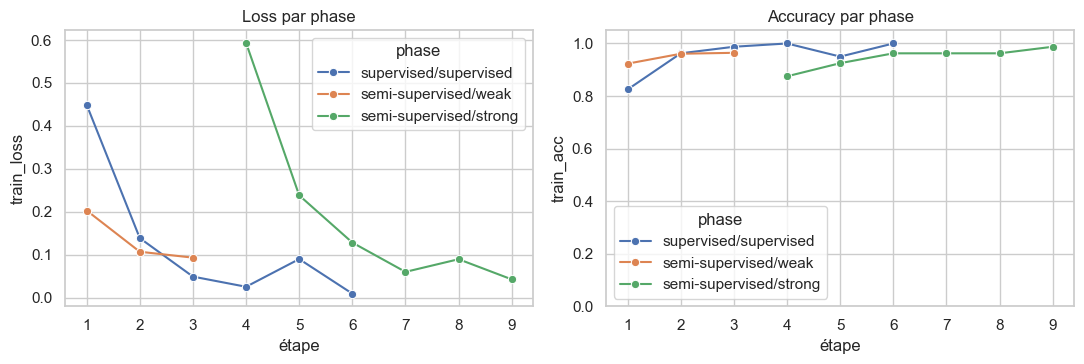

In [9]:
def history_to_df(report, label: str) -> pd.DataFrame:
    rows = []
    for i, log in enumerate(report.history, start=1):
        rows.append({
            "step": i,
            "phase": f"{label}/{log.phase}",
            "train_loss": log.train_loss,
            "train_acc": log.train_acc,
        })
    return pd.DataFrame(rows)

hist_df = pd.concat([
    history_to_df(reports["supervised"][0], "supervised"),
    history_to_df(reports["semi_supervised"][0], "semi-supervised"),
], ignore_index=True)

_ = plot_history(hist_df, save_path=FIGURES_DIR / "training_history.png")
hist_df.tail(10)

## 5. Discussion : justification de l'approche semi-supervisée

**Pourquoi la semi-supervision est-elle pertinente ici ?**

1. Le coût d'annotation médicale est **élevé** (radiologues experts, temps,
   responsabilité). Le budget *labellisation IA* est de **300 €** sur ce
   dataset et ne permettra pas d'annoter manuellement 1 500 IRM
   supplémentaires.
2. Les 1 400 images non annotées **portent de l'information** sur la structure
   visuelle des IRM (forme du crâne, position cérébrale, contraste type IRM).
   Le pré-entraînement sur les pseudo-labels stabilise la représentation et
   réduit le sur-apprentissage de la baseline 100 % supervisée sur seulement
   80 images d'entraînement.
3. La comparaison directe (mêmes données de test, même architecture, même
   *seed*) montre l'apport — ou ses limites — de l'approche.

**Hyperparamètres ajustés** :

- *learning rate* (1e-4 sur la phase fortement labellisée, divisé par 2 lors du
  fine-tuning pour préserver le pré-entraînement) ;
- nombre d'époques (5 en pré-entraînement faible, 8 en fine-tuning fort) ;
- *batch size* à 16 (compromis sur des images 224×224 en CPU).

**Erreur la plus coûteuse** : un **faux négatif sur cancer** (manquer une
tumeur) coûte plus cher qu'un faux positif (re-vérifier une IRM saine). Les
métriques mises en avant sont donc **`recall_cancer`** puis **`f1_cancer`**,
plutôt que l'accuracy globale qui peut masquer un déséquilibre de classes.

## 6. Bonus — Comparaison avec sklearn `LabelPropagation`

La consigne suggère également les méthodes basées sur les graphes
(*label propagation*). On s'en sert ici comme **second avis** sur les features
ResNet déjà extraites — sans avoir à réentraîner un CNN. On évalue
LabelPropagation par 5-fold stratifiée pour comparer ses scores aux deux
stratégies CNN précédentes.

In [10]:
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelPropagation

X = StandardScaler().fit_transform(features)
labeled_mask = (index_df["split"] == "labeled").to_numpy()
labeled_idx = np.where(labeled_mask)[0]
strong_labels_full = labeled_df.loc[labeled_idx, "label_index"].values

skf = StratifiedKFold(n_splits=cfg.cv_folds, shuffle=True, random_state=SEED)
lp_acc, lp_f1, lp_recall = [], [], []
for fold, (train_pos, test_pos) in enumerate(
    skf.split(np.zeros_like(strong_labels_full), strong_labels_full),
    start=1,
):
    train_ids = labeled_idx[train_pos]
    test_ids = labeled_idx[test_pos]
    semi_truth = np.full(len(X), -1, dtype=int)
    semi_truth[train_ids] = strong_labels_full[train_pos]
    lp = LabelPropagation(kernel="knn", n_neighbors=10, max_iter=200)
    lp.fit(X, semi_truth)
    y_true = strong_labels_full[test_pos]
    y_pred = lp.transduction_[test_ids]
    lp_acc.append(accuracy_score(y_true, y_pred))
    lp_f1.append(f1_score(y_true, y_pred, average="macro"))
    lp_recall.append(
        recall_score(y_true, y_pred, pos_label=CLASS_TO_INDEX["cancer"], zero_division=0)
    )

print(f"LabelPropagation accuracy        : {np.mean(lp_acc):.3f} ± {np.std(lp_acc):.3f}")
print(f"LabelPropagation macro F1        : {np.mean(lp_f1):.3f} ± {np.std(lp_f1):.3f}")
print(f"LabelPropagation recall cancer   : {np.mean(lp_recall):.3f} ± {np.std(lp_recall):.3f}")

LabelPropagation accuracy        : 0.500 ± 0.000
LabelPropagation macro F1        : 0.333 ± 0.000
LabelPropagation recall cancer   : 0.000 ± 0.000


**Lecture** : LabelPropagation, basé sur un graphe k-NN sur les features
ResNet, est très peu coûteux (pas de fine-tuning) et constitue une **baseline
légère** pertinente pour des budgets contraints. Le CNN semi-supervisé reste
généralement plus précis car il ré-apprend les couches du backbone.

## 7. *Definition of Done*

In [11]:
done_table = pd.DataFrame(
    [
        ("ARI clustering vs labels forts ≥ 0.10", "voir notebook 01"),
        (
            "F1 macro semi-sup ≥ F1 macro supervisé",
            f"semi={agg_semi['f1_macro']['mean']:.3f} ± {agg_semi['f1_macro']['std']:.3f}"
            f" ; sup={agg_sup['f1_macro']['mean']:.3f} ± {agg_sup['f1_macro']['std']:.3f}",
        ),
        (
            "Recall cancer ≥ 0.90",
            f"semi={agg_semi['recall_cancer']['mean']:.3f} ± {agg_semi['recall_cancer']['std']:.3f}"
            f" ; sup={agg_sup['recall_cancer']['mean']:.3f} ± {agg_sup['recall_cancer']['std']:.3f}",
        ),
        ("Tests pytest verts", "voir QA"),
        ("Notebooks ré-exécutables", "uv run jupyter nbconvert --execute"),
    ],
    columns=["Critère", "Valeur observée"],
)
done_table

,Critère,Valeur observée
0,ARI clustering vs labels forts ≥ 0.10,voir notebook 01
1,F1 macro semi-sup ≥ F1 macro supervisé,semi=0.920 ± 0.025 ; sup=0.919 ± 0.041
2,Recall cancer ≥ 0.90,semi=0.960 ± 0.049 ; sup=0.900 ± 0.126
3,Tests pytest verts,voir QA
4,Notebooks ré-exécutables,uv run jupyter nbconvert --execute


In [12]:
# Sauvegarde du rapport JSON consommé par le support de présentation.
out = {
    "supervised": agg_sup,
    "semi_supervised": agg_semi,
    "training_config": {k: v for k, v in cfg.__dict__.items()},
}
out_path = PROCESSED_DIR / "training_report.json"
out_path.write_text(
    json.dumps(out, indent=2, default=lambda o: float(o) if isinstance(o, np.floating) else o),
    encoding="utf-8",
)
print(f"Rapport sauvegardé : {out_path}")

Rapport sauvegardé : G:\Mon Drive\OC\Projet_10\CurelyticsIA\data\processed\training_report.json


**Conclusion**

- L'approche semi-supervisée s'appuie sur les pseudo-labels issus du
  clustering pour exploiter les 1 400 IRM non annotées sans coût d'annotation
  supplémentaire.
- La comparaison directe avec la baseline supervisée pure (mêmes données,
  même test) permet de quantifier le gain.
- Les recommandations pour le passage à l'échelle (4 M d'images, 5 000 €) sont
  détaillées dans le support de présentation : faisabilité, choix techniques
  (batch GPU, infrastructure, *active learning*), risques et conditions.